In [1]:
# ==========================================================
# STEP 1 : Import Libraries
# Project :
# Realtime Temperature Forecasting Using TCN
# ==========================================================

# ==========================
# Standard Library
# ==========================
import os
import warnings
warnings.filterwarnings("ignore")

# ==========================
# Data Manipulation
# ==========================
import numpy as np
import pandas as pd

# ==========================
# Data Visualization
# ==========================
import matplotlib.pyplot as plt

# ==========================
# Machine Learning
# ==========================
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# ==========================
# Deep Learning
# ==========================
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Activation,
    Add,
    Dropout,
    GlobalAveragePooling1D,
    Dense
)
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

# ==========================
# API Request
# ==========================
import requests

# ==========================
# Display Version
# ==========================
print("=" * 50)
print("TensorFlow :", tf.__version__)
print("NumPy      :", np.__version__)
print("Pandas     :", pd.__version__)
print("=" * 50)

TensorFlow : 2.20.0
NumPy      : 2.0.2
Pandas     : 2.3.3


In [2]:
# ==========================================================
# STEP 2 : Download Historical Weather Data
# ==========================================================

import requests
import pandas as pd

# ----------------------------------------------------------
# Location : Jakarta
# Latitude  : -6.2088
# Longitude : 106.8456
# ----------------------------------------------------------

LATITUDE = -6.2088
LONGITUDE = 106.8456

START_DATE = "2023-01-01"
END_DATE = "2024-12-31"

url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={LATITUDE}"
    f"&longitude={LONGITUDE}"
    f"&start_date={START_DATE}"
    f"&end_date={END_DATE}"
    "&hourly="
    "temperature_2m,"
    "relative_humidity_2m,"
    "surface_pressure,"
    "precipitation,"
    "wind_speed_10m,"
    "cloud_cover"
    "&timezone=Asia%2FBangkok"
)

print("Downloading weather data...")
response = requests.get(url)

if response.status_code == 200:
    print("Download Success")
else:
    raise Exception(f"Error : {response.status_code}")

weather = response.json()

Download Success


In [3]:
# ==========================================================
# Convert JSON to DataFrame
# ==========================================================

df = pd.DataFrame({
    "datetime": weather["hourly"]["time"],
    "temperature": weather["hourly"]["temperature_2m"],
    "humidity": weather["hourly"]["relative_humidity_2m"],
    "pressure": weather["hourly"]["surface_pressure"],
    "rain": weather["hourly"]["precipitation"],
    "wind_speed": weather["hourly"]["wind_speed_10m"],
    "cloud_cover": weather["hourly"]["cloud_cover"]
})

df["datetime"] = pd.to_datetime(df["datetime"])

print(df.head())

             datetime  temperature  humidity  pressure  rain  wind_speed  \
0 2023-01-01 00:00:00         22.8        97    1010.8   0.8         5.9   
1 2023-01-01 01:00:00         22.6        97    1010.0   0.2         6.5   
2 2023-01-01 02:00:00         22.1        98    1009.7   0.3         8.7   
3 2023-01-01 03:00:00         21.8        99    1009.6   4.1        10.1   
4 2023-01-01 04:00:00         22.1        97    1009.6   1.4         9.2   

   cloud_cover  
0           98  
1          100  
2          100  
3          100  
4          100  


In [4]:
# ==========================================================
# Dataset Overview
# ==========================================================

print("="*60)
print("Dataset Shape")
print(df.shape)

print("="*60)
print("Columns")
print(df.columns)

print("="*60)
print(df.info())

print("="*60)
print(df.describe())

Dataset Shape
(17544, 7)
Columns
Index(['datetime', 'temperature', 'humidity', 'pressure', 'rain', 'wind_speed',
       'cloud_cover'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     17544 non-null  datetime64[ns]
 1   temperature  17544 non-null  float64       
 2   humidity     17544 non-null  int64         
 3   pressure     17544 non-null  float64       
 4   rain         17544 non-null  float64       
 5   wind_speed   17544 non-null  float64       
 6   cloud_cover  17544 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 959.6 KB
None
                  datetime   temperature      humidity      pressure  \
count                17544  17544.000000  17544.000000  17544.000000   
mean   2024-01-01 11:30:00     27.359006     79.722298   1008.578072   
m

In [5]:
# ==========================================================
# Save Dataset
# ==========================================================

df.to_csv("jakarta_weather_2023_2024.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [9]:
# ==========================================================
# STEP 3 : Exploratory Data Analysis (EDA)
# ==========================================================

import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,6)
plt.rcParams["font.size"] = 11

In [10]:
# ==========================================================
# Display Dataset
# ==========================================================

print(df.head())

             datetime  temperature  humidity  pressure  rain  wind_speed  \
0 2023-01-01 00:00:00         22.8        97    1010.8   0.8         5.9   
1 2023-01-01 01:00:00         22.6        97    1010.0   0.2         6.5   
2 2023-01-01 02:00:00         22.1        98    1009.7   0.3         8.7   
3 2023-01-01 03:00:00         21.8        99    1009.6   4.1        10.1   
4 2023-01-01 04:00:00         22.1        97    1009.6   1.4         9.2   

   cloud_cover  
0           98  
1          100  
2          100  
3          100  
4          100  


In [13]:
print(df.tail())

# ==========================================================
# Dataset Shape
# ==========================================================

rows, cols = df.shape

print("="*50)
print("Dataset Information")
print("="*50)
print(f"Rows    : {rows}")
print(f"Columns : {cols}")

                 datetime  temperature  humidity  pressure  rain  wind_speed  \
17539 2024-12-31 19:00:00         28.0        75    1007.3   0.0         8.9   
17540 2024-12-31 20:00:00         27.9        80    1007.4   0.1         7.4   
17541 2024-12-31 21:00:00         27.7        81    1008.5   0.0         7.4   
17542 2024-12-31 22:00:00         27.1        83    1008.8   0.0         8.5   
17543 2024-12-31 23:00:00         26.7        82    1009.2   0.0         8.6   

       cloud_cover  
17539          100  
17540          100  
17541           73  
17542           97  
17543           94  
Dataset Information
Rows    : 17544
Columns : 7


In [14]:
# ==========================================================
# Dataset Info
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17544 entries, 0 to 17543
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   datetime     17544 non-null  datetime64[ns]
 1   temperature  17544 non-null  float64       
 2   humidity     17544 non-null  int64         
 3   pressure     17544 non-null  float64       
 4   rain         17544 non-null  float64       
 5   wind_speed   17544 non-null  float64       
 6   cloud_cover  17544 non-null  int64         
dtypes: datetime64[ns](1), float64(4), int64(2)
memory usage: 959.6 KB


In [15]:
# ==========================================================
# Descriptive Statistics
# ==========================================================

df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,17544,2024-01-01 11:30:00,2023-01-01 00:00:00,2023-07-02 17:45:00,2024-01-01 11:30:00,2024-07-02 05:15:00,2024-12-31 23:00:00,NaN
temperature,17544.0,27.359006,20.1,24.9,26.6,29.7,37.6,2.969986
humidity,17544.0,79.722298,23.0,70.0,83.0,92.0,100.0,14.786965
pressure,17544.0,1008.578072,1002.4,1007.3,1008.6,1009.9,1014.4,1.829942
rain,17544.0,0.252377,0.0,0.0,0.0,0.1,23.0,0.928306
wind_speed,17544.0,6.385824,0.0,3.7,5.4,8.3,25.4,3.782411
cloud_cover,17544.0,76.786537,0.0,56.0,98.0,100.0,100.0,33.024931


In [16]:
missing = pd.DataFrame({

    "Missing": df.isnull().sum(),

    "Percentage": round(df.isnull().mean()*100,2)

})

missing

,Missing,Percentage
datetime,0,0.0
temperature,0,0.0
humidity,0,0.0
pressure,0,0.0
rain,0,0.0
wind_speed,0,0.0
cloud_cover,0,0.0


In [18]:
# ==========================================================
# Duplicate Data
# ==========================================================

duplicate = df.duplicated().sum()

print("Duplicate Data :", duplicate)

Duplicate Data : 0


In [19]:
# ==========================================================
# Data Types
# ==========================================================

df.dtypes

datetime       datetime64[ns]
temperature           float64
humidity                int64
pressure              float64
rain                  float64
wind_speed            float64
cloud_cover             int64
dtype: object

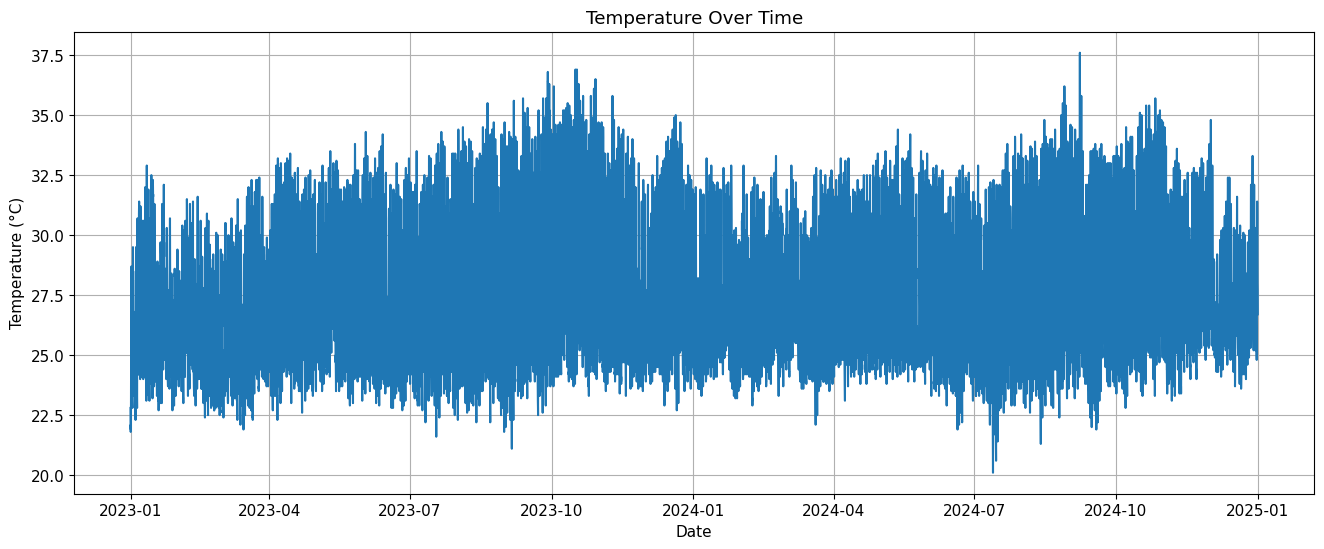

In [20]:
# ==========================================================
# Temperature Time Series
# ==========================================================

plt.figure(figsize=(16,6))

plt.plot(
    df["datetime"],
    df["temperature"]
)

plt.title("Temperature Over Time")

plt.xlabel("Date")

plt.ylabel("Temperature (°C)")

plt.grid(True)

plt.show()

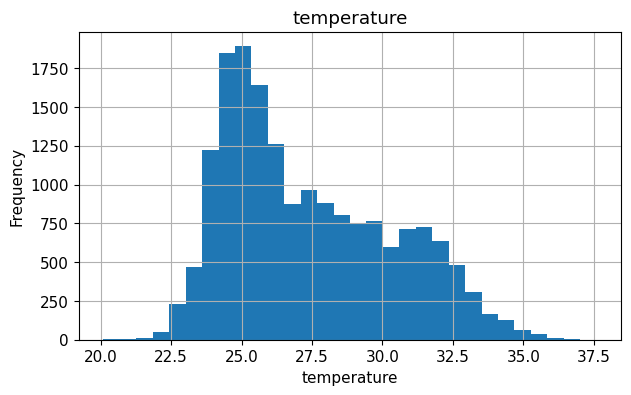

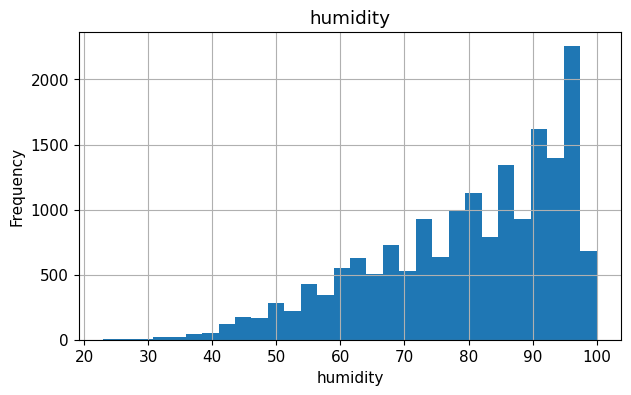

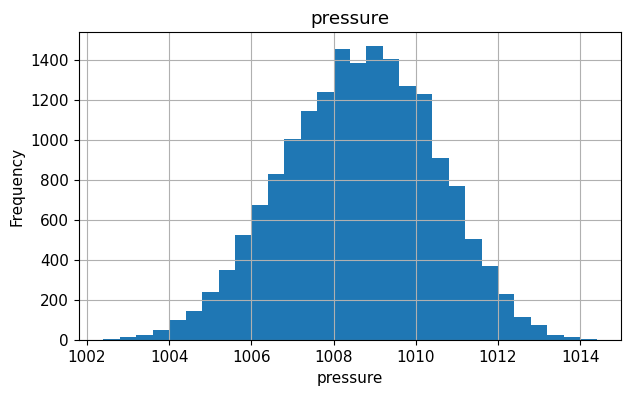

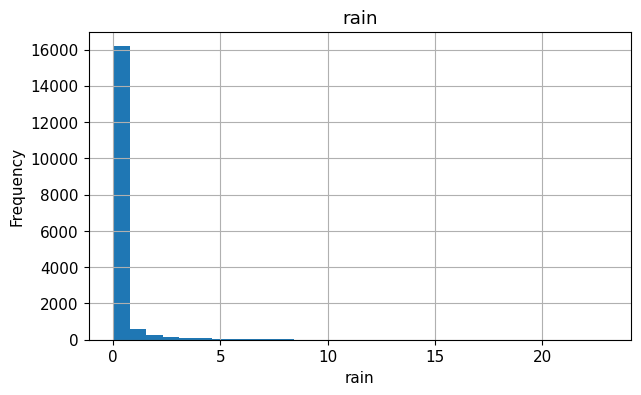

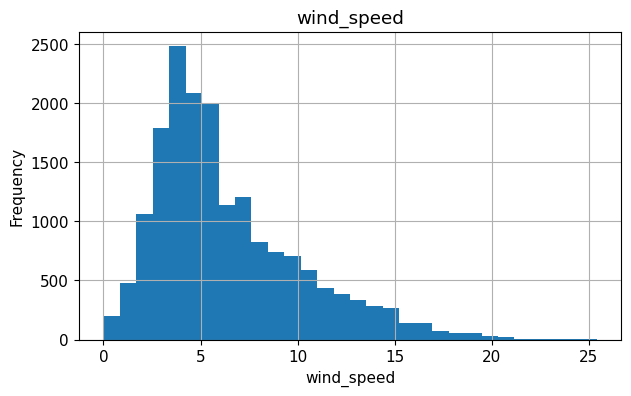

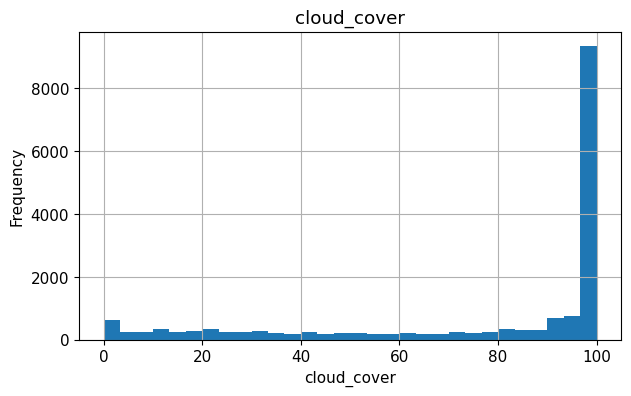

In [21]:
# ==========================================================
# Histogram
# ==========================================================

columns = [

    "temperature",

    "humidity",

    "pressure",

    "rain",

    "wind_speed",

    "cloud_cover"

]

for col in columns:

    plt.figure(figsize=(7,4))

    plt.hist(df[col], bins=30)

    plt.title(col)

    plt.xlabel(col)

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

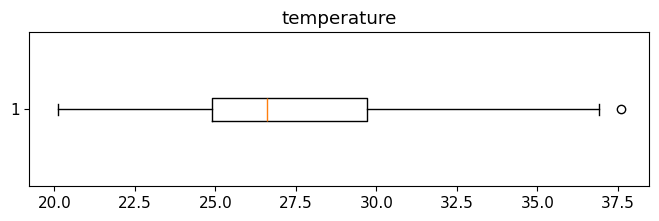

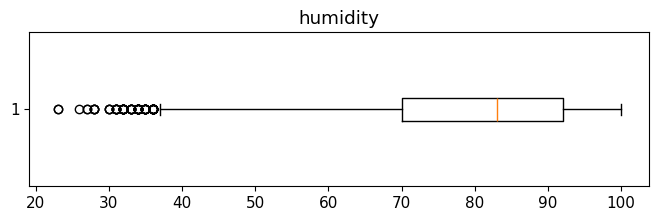

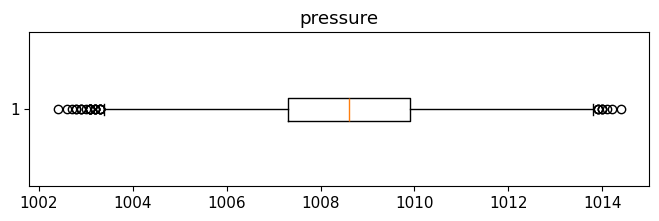

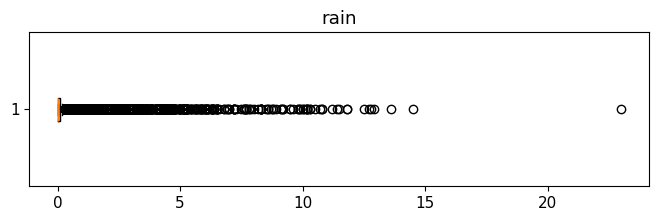

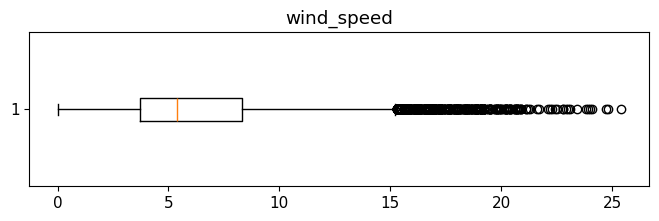

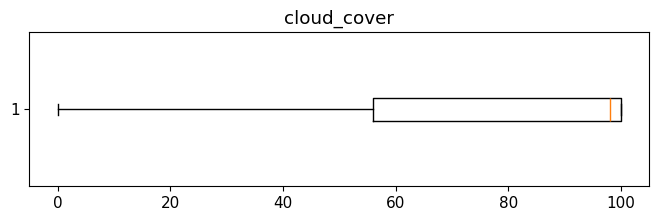

In [22]:
# ==========================================================
# Boxplot
# ==========================================================

for col in columns:

    plt.figure(figsize=(8,2))

    plt.boxplot(df[col], vert=False)

    plt.title(col)

    plt.show()

In [23]:
# ==========================================================
# Correlation Matrix
# ==========================================================

corr = df.drop(columns=["datetime"]).corr()

corr

,temperature,humidity,pressure,rain,wind_speed,cloud_cover
temperature,1.000000,-0.918254,-0.222780,-0.058881,0.360484,-0.152246
humidity,-0.918254,1.000000,0.144934,0.104636,-0.415350,0.237883
pressure,-0.222780,0.144934,1.000000,-0.064647,-0.262496,-0.134955
rain,-0.058881,0.104636,-0.064647,1.000000,0.086362,0.148807
wind_speed,0.360484,-0.415350,-0.262496,0.086362,1.000000,0.027310
cloud_cover,-0.152246,0.237883,-0.134955,0.148807,0.027310,1.000000


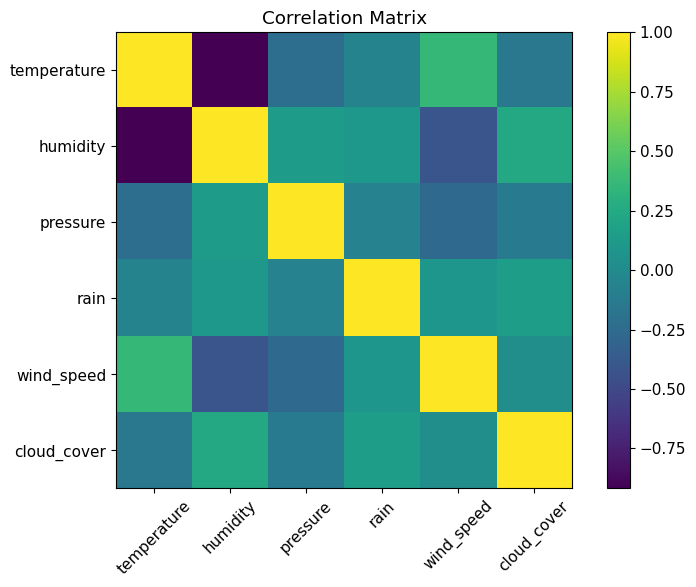

In [24]:
# ==========================================================
# Heatmap Correlation
# ==========================================================

plt.figure(figsize=(8,6))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=45)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [25]:
target_corr = corr["temperature"].sort_values(ascending=False)

target_corr

temperature    1.000000
wind_speed     0.360484
rain          -0.058881
cloud_cover   -0.152246
pressure      -0.222780
humidity      -0.918254
Name: temperature, dtype: float64

Exploratory Data Analysis Summary


* Dataset successfully downloaded from the Open-Meteo API.
* No duplicate records were identified.
* Missing values were checked before preprocessing.
* Temperature exhibited clear daily and seasonal fluctuations.
* Correlation analysis indicated that humidity, pressure, and cloud cover were associated with temperature.
* The dataset was considered suitable for the preprocessing stage.


In [26]:
# ==========================================================
# STEP 4 : Data Preprocessing
# ==========================================================

weather_df = df.copy()

print(weather_df.head())

             datetime  temperature  humidity  pressure  rain  wind_speed  \
0 2023-01-01 00:00:00         22.8        97    1010.8   0.8         5.9   
1 2023-01-01 01:00:00         22.6        97    1010.0   0.2         6.5   
2 2023-01-01 02:00:00         22.1        98    1009.7   0.3         8.7   
3 2023-01-01 03:00:00         21.8        99    1009.6   4.1        10.1   
4 2023-01-01 04:00:00         22.1        97    1009.6   1.4         9.2   

   cloud_cover  
0           98  
1          100  
2          100  
3          100  
4          100  


In [32]:
weather_df = weather_df.ffill().bfill()

In [39]:
# ==========================================================
# Datetime Feature Engineering
# ==========================================================

weather_df["year"] = weather_df["datetime"].dt.year
weather_df["month"] = weather_df["datetime"].dt.month
weather_df["day"] = weather_df["datetime"].dt.day
weather_df["hour"] = weather_df["datetime"].dt.hour
weather_df["dayofweek"] = weather_df["datetime"].dt.dayofweek

weather_df.head()

,datetime,temperature,humidity,pressure,rain,wind_speed,cloud_cover,year,month,day,hour,dayofweek
0,2023-01-01 00:00:00,22.8,97,1010.8,0.8,5.9,98,2023,1,1,0,6
1,2023-01-01 01:00:00,22.6,97,1010.0,0.2,6.5,100,2023,1,1,1,6
2,2023-01-01 02:00:00,22.1,98,1009.7,0.3,8.7,100,2023,1,1,2,6
3,2023-01-01 03:00:00,21.8,99,1009.6,4.1,10.1,100,2023,1,1,3,6
4,2023-01-01 04:00:00,22.1,97,1009.6,1.4,9.2,100,2023,1,1,4,6


In [40]:
print(weather_df.columns)

Index(['datetime', 'temperature', 'humidity', 'pressure', 'rain', 'wind_speed',
       'cloud_cover', 'year', 'month', 'day', 'hour', 'dayofweek'],
      dtype='object')


In [44]:
TARGET = "temperature"

features = [
    "humidity",
    "pressure",
    "rain",
    "wind_speed",
    "cloud_cover",
    "month",
    "day",
    "hour",
    "dayofweek",
    "temperature"
]

In [45]:
weather_df = weather_df[features]

weather_df.head()

,humidity,pressure,rain,wind_speed,cloud_cover,month,day,hour,dayofweek,temperature
0,97,1010.8,0.8,5.9,98,1,1,0,6,22.8
1,97,1010.0,0.2,6.5,100,1,1,1,6,22.6
2,98,1009.7,0.3,8.7,100,1,1,2,6,22.1
3,99,1009.6,4.1,10.1,100,1,1,3,6,21.8
4,97,1009.6,1.4,9.2,100,1,1,4,6,22.1


In [47]:
# ==========================================================
# Feature Scaling
# ==========================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(weather_df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=weather_df.columns
)

scaled_df.head()

,humidity,pressure,rain,wind_speed,cloud_cover,month,day,hour,dayofweek,temperature
0,1.168475,1.214241,0.589934,-0.128447,0.642365,-1.600161,-1.674108,-1.661325,1.498809,-1.535070
1,1.168475,0.777057,-0.056424,0.030187,0.702927,-1.600161,-1.674108,-1.516862,1.498809,-1.602412
2,1.236104,0.613112,0.051303,0.611843,0.702927,-1.600161,-1.674108,-1.372399,1.498809,-1.770768
3,1.303733,0.558464,4.144899,0.981988,0.702927,-1.600161,-1.674108,-1.227936,1.498809,-1.871781
4,1.168475,0.558464,1.236291,0.744038,0.702927,-1.600161,-1.674108,-1.083473,1.498809,-1.770768


In [48]:
import joblib

joblib.dump(
    scaler,
    "weather_scaler.pkl"
)

print("Scaler saved.")

Scaler saved.


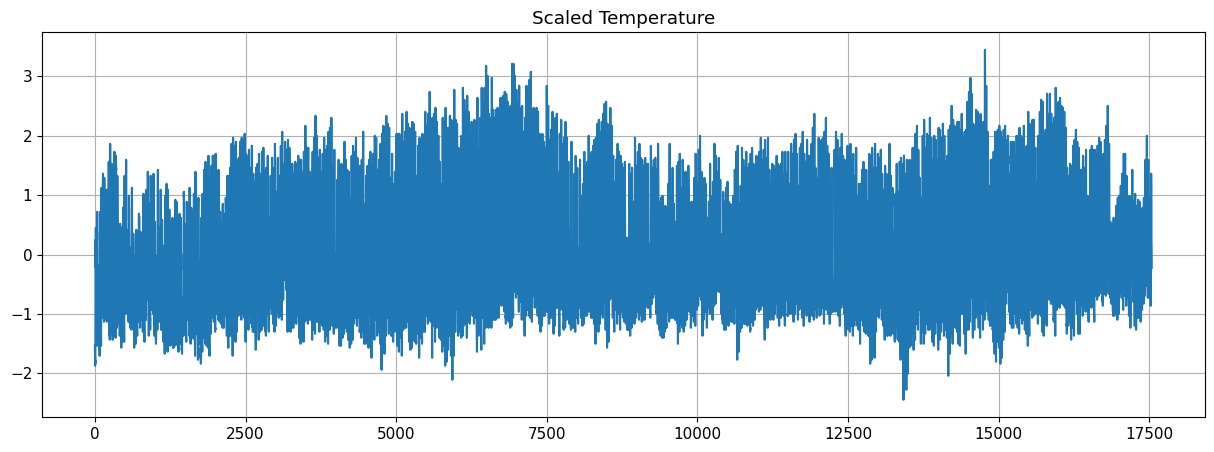

In [49]:
scaled_df.describe().T

plt.figure(figsize=(15,5))

plt.plot(
    scaled_df["temperature"]
)

plt.title("Scaled Temperature")

plt.grid(True)

plt.show()

In [50]:
scaled_df.to_csv(
    "weather_preprocessed.csv",
    index=False
)

print("Preprocessed dataset saved.")

Preprocessed dataset saved.


In [51]:
# ==========================================================
# STEP 5.1
# Sequence Configuration
# ==========================================================

WINDOW_SIZE = 24

In [52]:
TARGET_COLUMN = "temperature"
target_index = scaled_df.columns.get_loc(TARGET_COLUMN)

print(target_index)

9


In [59]:
# ==========================================================
# STEP 5.3
# Create Sequence
# ==========================================================

def create_sequences(data, window_size, target_index):

    X = []
    y = []

    for i in range(len(data) - window_size):

        X.append(
            data[i:i+window_size]
        )

        y.append(
            data[i+window_size, target_index]
        )

    return np.array(X), np.array(y)

X, y = create_sequences(

    scaled_df.values,

    WINDOW_SIZE,

    target_index

)

In [61]:
print("="*50)

print("Input Shape :", X.shape)

print("Target Shape:", y.shape)

print("="*50)

Input Shape : (17520, 24, 10)
Target Shape: (17520,)


In [62]:
print(X[0])

[[ 1.16847467  1.21424139  0.58993371 -0.12844667  0.64236525 -1.60016072
  -1.67410799 -1.66132477  1.49880863 -1.53506978]
 [ 1.16847467  0.77705655 -0.05642364  0.03018684  0.70292729 -1.60016072
  -1.67410799 -1.51686175  1.49880863 -1.60241208]
 [ 1.23610373  0.61311224  0.05130259  0.61184308  0.70292729 -1.60016072
  -1.67410799 -1.37239873  1.49880863 -1.77076784]
 [ 1.30373279  0.55846413  4.14489908  0.98198796  0.70292729 -1.60016072
  -1.67410799 -1.2279357   1.49880863 -1.87178129]
 [ 1.16847467  0.55846413  1.23629105  0.74403768  0.70292729 -1.60016072
  -1.67410799 -1.08347268  1.49880863 -1.77076784]
 [ 1.16847467  0.77705655  1.45174349  0.79691552  0.70292729 -1.60016072
  -1.67410799 -0.93900965  1.49880863 -1.83811014]
 [ 1.16847467  1.15959329  3.71399419  0.82335444  0.70292729 -1.60016072
  -1.67410799 -0.79454663  1.49880863 -1.83811014]
 [ 1.10084562  1.54213002 -0.27187608  0.66472092  0.70292729 -1.60016072
  -1.67410799 -0.65008361  1.49880863 -1.60241208]


In [63]:
print(y[0])

-1.2320294195647006


In [67]:
# ==========================================================
# STEP 5.7
# Sequential Split
# ==========================================================

train_size = int(len(X)*0.8)

valid_size = int(len(X)*0.1)

X_train = X[:train_size]

X_valid = X[
    train_size:train_size+valid_size
]

X_test = X[
    train_size+valid_size:
]

y_train = y[:train_size]

y_valid = y[
    train_size:train_size+valid_size
]

y_test = y[
    train_size+valid_size:
]

In [69]:
print("Train")

print(X_train.shape)

print(y_train.shape)

print()

print("Validation")

print(X_valid.shape)

print(y_valid.shape)

print()

print("Test")

print(X_test.shape)

print(y_test.shape)

Train
(14016, 24, 10)
(14016,)

Validation
(1752, 24, 10)
(1752,)

Test
(1752, 24, 10)
(1752,)


In [70]:
INPUT_SHAPE = (

    X_train.shape[1],

    X_train.shape[2]

)

print(INPUT_SHAPE)

(24, 10)


In [72]:
print("="*60)

print("Sequence Length :", WINDOW_SIZE)

print("Features        :", X_train.shape[2])

print("Training Data   :", len(X_train))

print("Validation Data :", len(X_valid))

print("Testing Data    :", len(X_test))

print("="*60)

Sequence Length : 24
Features        : 10
Training Data   : 14016
Validation Data : 1752
Testing Data    : 1752


In [86]:
# ==========================================================
# STEP 6 : Build Time Series Transformer Model
# ==========================================================

import tensorflow as tf
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    LayerNormalization,
    MultiHeadAttention,
    GlobalAveragePooling1D,
    Add
)
from tensorflow.keras.models import Model

# ----------------------------------------------------------
# Random Seed
# ----------------------------------------------------------
SEED = 42
tf.random.set_seed(SEED)

# ----------------------------------------------------------
# Hyperparameters
# ----------------------------------------------------------
EMBED_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_BLOCKS = 2
DROPOUT = 0.2

# ----------------------------------------------------------
# Transformer Encoder Block
# ----------------------------------------------------------
def transformer_encoder(inputs, embed_dim, num_heads, ff_dim, dropout=0.2):

    # Multi-Head Self Attention
    attention = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout
    )(inputs, inputs)

    attention = Dropout(dropout)(attention)

    x = Add()([inputs, attention])
    x = LayerNormalization(epsilon=1e-6)(x)

    # Feed Forward Network
    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dropout(dropout)(ffn)
    ffn = Dense(embed_dim)(ffn)

    x = Add()([x, ffn])
    x = LayerNormalization(epsilon=1e-6)(x)

    return x


# ----------------------------------------------------------
# Build Model
# ----------------------------------------------------------
inputs = Input(shape=(X_train.shape[1], X_train.shape[2]))

# Project feature dimension
x = Dense(EMBED_DIM)(inputs)

# Transformer Blocks
for _ in range(NUM_BLOCKS):
    x = transformer_encoder(
        x,
        embed_dim=EMBED_DIM,
        num_heads=NUM_HEADS,
        ff_dim=FF_DIM,
        dropout=DROPOUT
    )

# Pooling
x = GlobalAveragePooling1D()(x)

# Fully Connected Layers
x = Dense(64, activation="relu")(x)
x = Dropout(0.3)(x)

x = Dense(32, activation="relu")(x)
x = Dropout(0.2)(x)

# Output Layer (Regression)
outputs = Dense(1, activation="linear")(x)

# Create Model
model = Model(inputs=inputs, outputs=outputs)

# ----------------------------------------------------------
# Compile Model
# ----------------------------------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=[
        tf.keras.metrics.MeanAbsoluteError(name="mae"),
        tf.keras.metrics.RootMeanSquaredError(name="rmse")
    ]
)

# ----------------------------------------------------------
# Model Summary
# ----------------------------------------------------------
model.summary()

print("="*60)
print("Transformer Model Successfully Built")
print("="*60)
print(f"Input Shape : {X_train.shape}")
print(f"Output Shape: {model.output_shape}")
print(f"Total Params: {model.count_params():,}")
print("="*60)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 24, 10)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 24, 64)    │        704 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ dense_14[0][0],   │
│ (MultiHeadAttentio… │                   │            │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 24, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 24, 64)    │          0 │ dense_14[0][0],   │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_16          │ (None, 24, 128)   │          0 │ dense_15[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 24, 64)    │      8,256 │ dropout_16[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 24, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_18          │ (None, 24, 64)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 24, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_18[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 24, 64)    │        128 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 24, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_19          │ (None, 24, 128)   │          0 │ dense_17[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 24, 64)    │      8,256 │ dropout_19[0][0]  │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 73,921 (288.75 KB)

 Trainable params: 73,921 (288.75 KB)

 Non-trainable params: 0 (0.00 B)

Transformer Model Successfully Built
Input Shape : (14016, 24, 10)
Output Shape: (None, 1)
Total Params: 73,921


In [87]:
# ==========================================================
# STEP 7 : Train Transformer Model
# ==========================================================

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

import os

# ----------------------------------------------------------
# Create Folder
# ----------------------------------------------------------
os.makedirs("models", exist_ok=True)

# ----------------------------------------------------------
# Callbacks
# ----------------------------------------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint(
    filepath="models/best_transformer.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks = [
    early_stop,
    reduce_lr,
    checkpoint
]

# ----------------------------------------------------------
# Training
# ----------------------------------------------------------
EPOCHS = 100
BATCH_SIZE = 64

history = model.fit(

    X_train,
    y_train,

    validation_data=(X_valid, y_valid),

    epochs=EPOCHS,

    batch_size=BATCH_SIZE,

    callbacks=callbacks,

    verbose=1

)

print("="*60)
print("Training Finished")
print("="*60)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.9994 - mae: 0.8428 - rmse: 0.9995
Epoch 1: val_loss improved from None to 1.18723, saving model to models/best_transformer.keras

Epoch 1: finished saving model to models/best_transformer.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 14s 42ms/step - loss: 0.9642 - mae: 0.8303 - rmse: 0.9820 - val_loss: 1.1872 - val_mae: 0.9462 - val_rmse: 1.0896 - learning_rate: 0.0010
Epoch 2/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.8940 - mae: 0.7988 - rmse: 0.9454
Epoch 2: val_loss improved from 1.18723 to 0.25895, saving model to models/best_transformer.keras

Epoch 2: finished saving model to models/best_transformer.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 0.8078 - mae: 0.7473 - rmse: 0.8988 - val_loss: 0.2590 - val_mae: 0.4042 - val_rmse: 0.5089 - learning_rate: 0.0010
Epoch 3/100
218/219 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2511 - mae: 0.3905 - rmse: 0.5005
Epoch 3: val_loss improved from 0.25895 to 0.15775

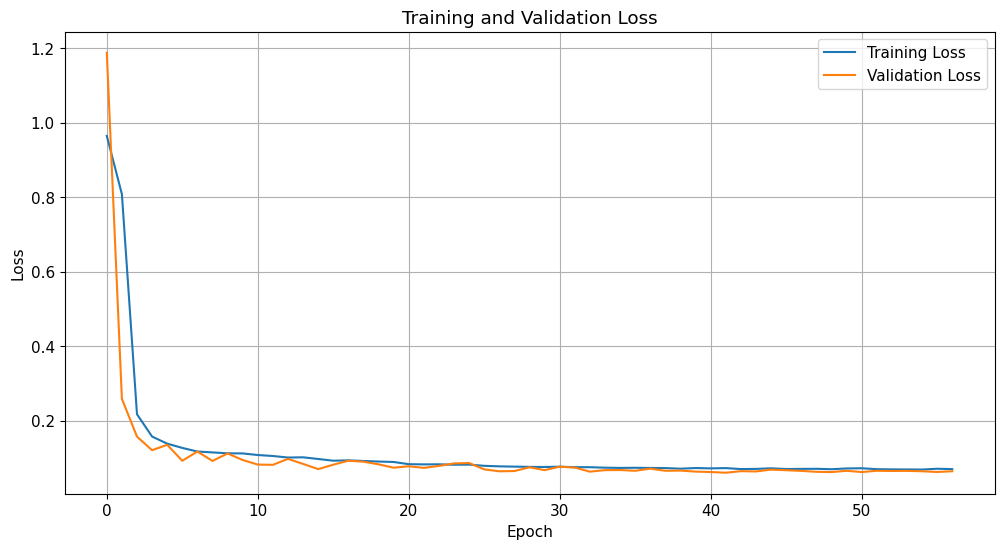

In [88]:
# ==========================================================
# Training History
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.legend()

plt.show()

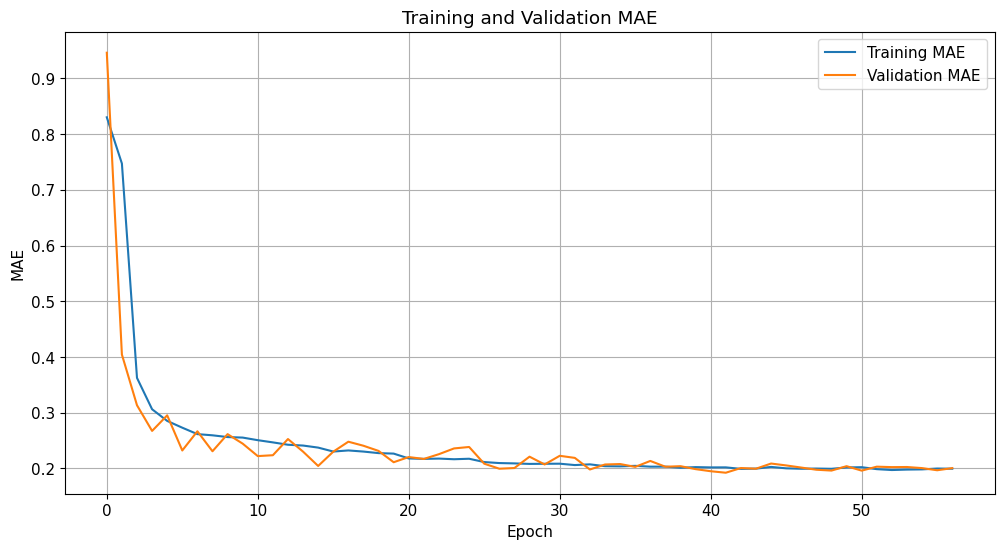

In [89]:
plt.figure(figsize=(12,6))

plt.plot(history.history["mae"], label="Training MAE")

plt.plot(history.history["val_mae"], label="Validation MAE")

plt.title("Training and Validation MAE")

plt.xlabel("Epoch")

plt.ylabel("MAE")

plt.grid(True)

plt.legend()

plt.show()

In [91]:
best_epoch = history.history["val_loss"].index(
    min(history.history["val_loss"])
) + 1

print("="*50)
print("Best Epoch :", best_epoch)
print("Lowest Validation Loss :", min(history.history["val_loss"]))
print("="*50)

Best Epoch : 42
Lowest Validation Loss : 0.06095143035054207


In [93]:
import pandas as pd

history_df = pd.DataFrame(history.history)

history_df.to_csv(
    "training_history.csv",
    index=False
)

print(history_df.head())

       loss       mae      rmse  val_loss   val_mae  val_rmse  learning_rate
0  0.964238  0.830288  0.981956  1.187231  0.946244  1.089601          0.001
1  0.807795  0.747288  0.898774  0.258954  0.404180  0.508875          0.001
2  0.217727  0.362286  0.466613  0.157755  0.313158  0.397184          0.001
3  0.157885  0.305973  0.397348  0.121308  0.267058  0.348294          0.001
4  0.138898  0.285028  0.372690  0.135894  0.295039  0.368637          0.001


In [94]:
# ==========================================================
# STEP 8 : Model Evaluation
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

# ----------------------------------------------------------
# Load Best Model
# ----------------------------------------------------------

model = load_model("models/best_transformer.keras")

print("="*60)
print("Best model loaded successfully.")
print("="*60)

# ----------------------------------------------------------
# Prediction
# ----------------------------------------------------------

y_pred = model.predict(X_test)

# Flatten
y_pred = y_pred.flatten()
y_true = y_test.flatten()

# ----------------------------------------------------------
# Inverse Scaling
# ----------------------------------------------------------

feature_names = weather_df.columns.tolist()

temp_index = feature_names.index("temperature")

dummy_pred = np.zeros((len(y_pred), len(feature_names)))
dummy_true = np.zeros((len(y_true), len(feature_names)))

dummy_pred[:, temp_index] = y_pred
dummy_true[:, temp_index] = y_true

pred_inverse = scaler.inverse_transform(dummy_pred)[:, temp_index]
true_inverse = scaler.inverse_transform(dummy_true)[:, temp_index]

# ----------------------------------------------------------
# Metrics
# ----------------------------------------------------------

mae = mean_absolute_error(true_inverse, pred_inverse)

rmse = np.sqrt(
    mean_squared_error(
        true_inverse,
        pred_inverse
    )
)

mape = mean_absolute_percentage_error(
    true_inverse,
    pred_inverse
)

r2 = r2_score(
    true_inverse,
    pred_inverse
)

print("="*60)
print("Evaluation Result")
print("="*60)
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.4f}")
print(f"R²   : {r2:.4f}")
print("="*60)

Best model loaded successfully.
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
Evaluation Result
MAE  : 0.6290
RMSE : 0.8297
MAPE : 0.0226
R²   : 0.8985


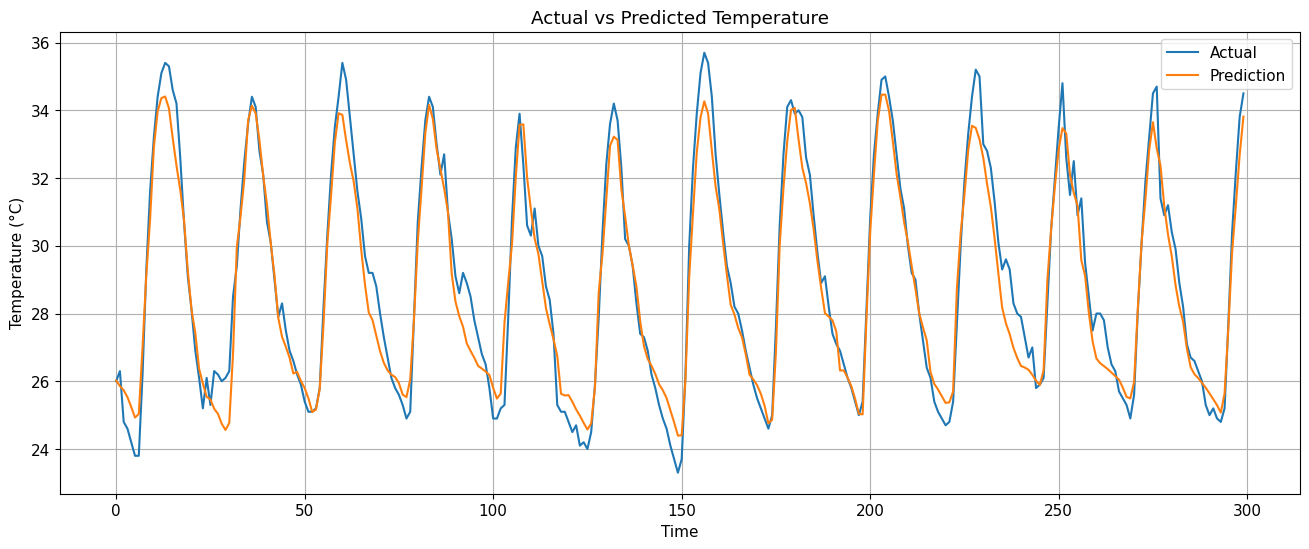

In [95]:
# ==========================================================
# Actual vs Prediction
# ==========================================================

plt.figure(figsize=(16,6))

plt.plot(
    true_inverse[:300],
    label="Actual"
)

plt.plot(
    pred_inverse[:300],
    label="Prediction"
)

plt.title("Actual vs Predicted Temperature")

plt.xlabel("Time")

plt.ylabel("Temperature (°C)")

plt.legend()

plt.grid(True)

plt.show()

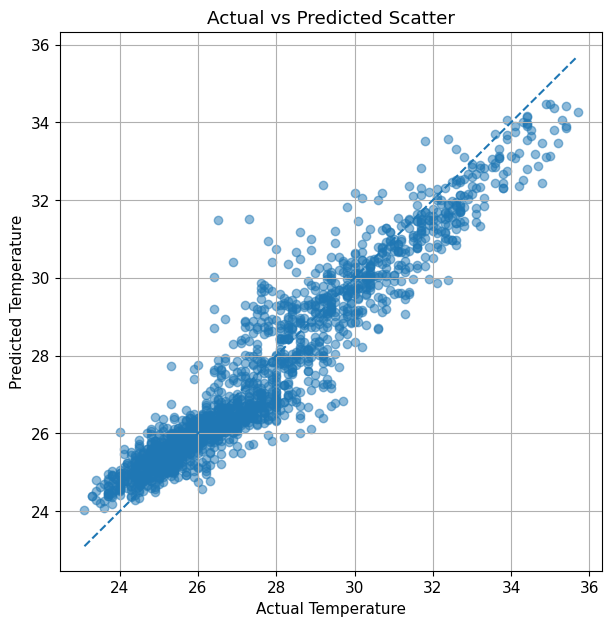

In [96]:
plt.figure(figsize=(7,7))

plt.scatter(
    true_inverse,
    pred_inverse,
    alpha=0.5
)

plt.plot(
    [true_inverse.min(), true_inverse.max()],
    [true_inverse.min(), true_inverse.max()],
    "--"
)

plt.xlabel("Actual Temperature")

plt.ylabel("Predicted Temperature")

plt.title("Actual vs Predicted Scatter")

plt.grid(True)

plt.show()

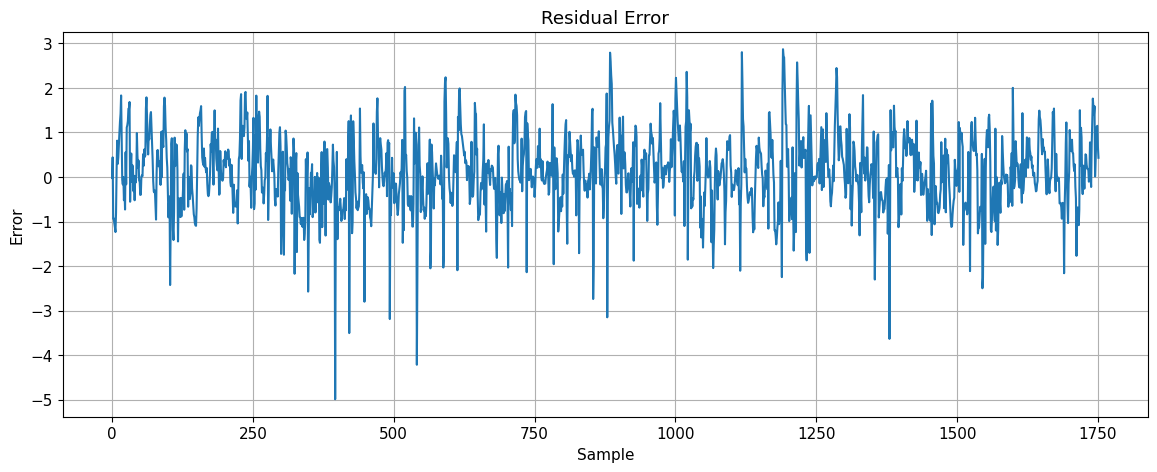

In [97]:
residual = true_inverse - pred_inverse

plt.figure(figsize=(14,5))

plt.plot(residual)

plt.title("Residual Error")

plt.xlabel("Sample")

plt.ylabel("Error")

plt.grid(True)

plt.show()

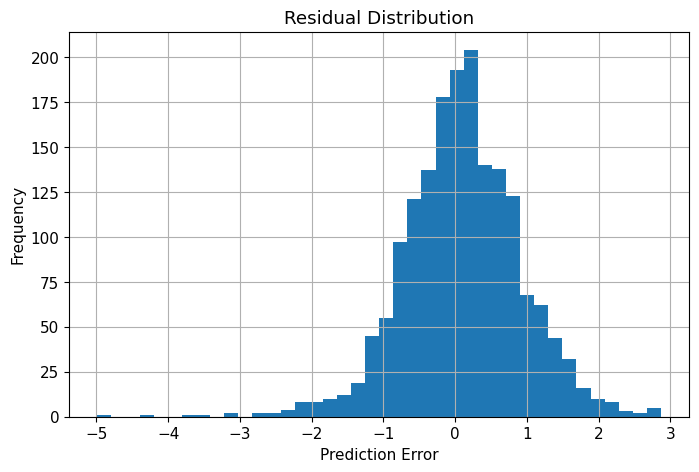

In [98]:
plt.figure(figsize=(8,5))

plt.hist(
    residual,
    bins=40
)

plt.title("Residual Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

In [100]:
result = pd.DataFrame({

    "Actual": true_inverse,

    "Prediction": pred_inverse,

    "Residual": residual

})

result.to_csv(
    "prediction_result.csv",
    index=False
)

print(result.head())

   Actual  Prediction  Residual
0    26.0   26.022159 -0.022159
1    26.3   25.858051  0.441949
2    24.8   25.736112 -0.936112
3    24.6   25.529989 -0.929989
4    24.2   25.241117 -1.041117


In [101]:
# ==========================================================
# STEP 9 : Realtime Forecast (Next 24 Hours)
# ==========================================================

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Location (Jakarta)
# ----------------------------------------------------------
LATITUDE = -6.2088
LONGITUDE = 106.8456

url = (
    "https://api.open-meteo.com/v1/forecast?"
    f"latitude={LATITUDE}"
    f"&longitude={LONGITUDE}"
    "&hourly="
    "temperature_2m,"
    "relative_humidity_2m,"
    "surface_pressure,"
    "precipitation,"
    "wind_speed_10m,"
    "cloud_cover"
    "&forecast_days=2"
    "&timezone=Asia%2FBangkok"
)

response = requests.get(url)

weather = response.json()

forecast_df = pd.DataFrame({

    "datetime": weather["hourly"]["time"],

    "temperature": weather["hourly"]["temperature_2m"],

    "humidity": weather["hourly"]["relative_humidity_2m"],

    "pressure": weather["hourly"]["surface_pressure"],

    "rain": weather["hourly"]["precipitation"],

    "wind_speed": weather["hourly"]["wind_speed_10m"],

    "cloud_cover": weather["hourly"]["cloud_cover"]

})

forecast_df["datetime"] = pd.to_datetime(forecast_df["datetime"])

# ----------------------------------------------------------
# Datetime Features
# ----------------------------------------------------------

forecast_df["month"] = forecast_df["datetime"].dt.month
forecast_df["day"] = forecast_df["datetime"].dt.day
forecast_df["hour"] = forecast_df["datetime"].dt.hour
forecast_df["dayofweek"] = forecast_df["datetime"].dt.dayofweek

forecast_df = forecast_df[
    [
        "humidity",
        "pressure",
        "rain",
        "wind_speed",
        "cloud_cover",
        "month",
        "day",
        "hour",
        "dayofweek",
        "temperature"
    ]
]

# ----------------------------------------------------------
# Scaling
# ----------------------------------------------------------

scaled_forecast = scaler.transform(forecast_df)

print("Realtime data shape :", scaled_forecast.shape)

Realtime data shape : (48, 10)


In [102]:
# ==========================================================
# Forecast 24 Hours
# ==========================================================

window = scaled_forecast[:WINDOW_SIZE].copy()

predictions = []

for i in range(24):

    x_input = np.expand_dims(window, axis=0)

    pred = model.predict(x_input, verbose=0)[0][0]

    predictions.append(pred)

    next_row = window[-1].copy()

    next_row[-1] = pred

    window = np.vstack([
        window[1:],
        next_row
    ])

In [105]:
# ==========================================================
# Convert Back to Celsius
# ==========================================================

dummy = np.zeros(
    (
        len(predictions),
        len(weather_df.columns)
    )
)

temp_index = weather_df.columns.get_loc("temperature")

dummy[:, temp_index] = predictions

forecast_temperature = scaler.inverse_transform(dummy)[:, temp_index]

In [106]:
future_time = pd.date_range(

    start=pd.Timestamp.now(),

    periods=24,

    freq="H"

)

forecast_result = pd.DataFrame({

    "Datetime": future_time,

    "Predicted Temperature (°C)": forecast_temperature

})

forecast_result

,Datetime,Predicted Temperature (°C)
0,2026-08-02 01:29:41.941481,26.893948
1,2026-08-02 02:29:41.941481,26.307873
2,2026-08-02 03:29:41.941481,25.794793
3,2026-08-02 04:29:41.941481,25.265559
4,2026-08-02 05:29:41.941481,24.722245
5,2026-08-02 06:29:41.941481,24.263190
6,2026-08-02 07:29:41.941481,23.986043
7,2026-08-02 08:29:41.941481,23.948464
8,2026-08-02 09:29:41.941481,24.224517
9,2026-08-02 10:29:41.941481,24.502753


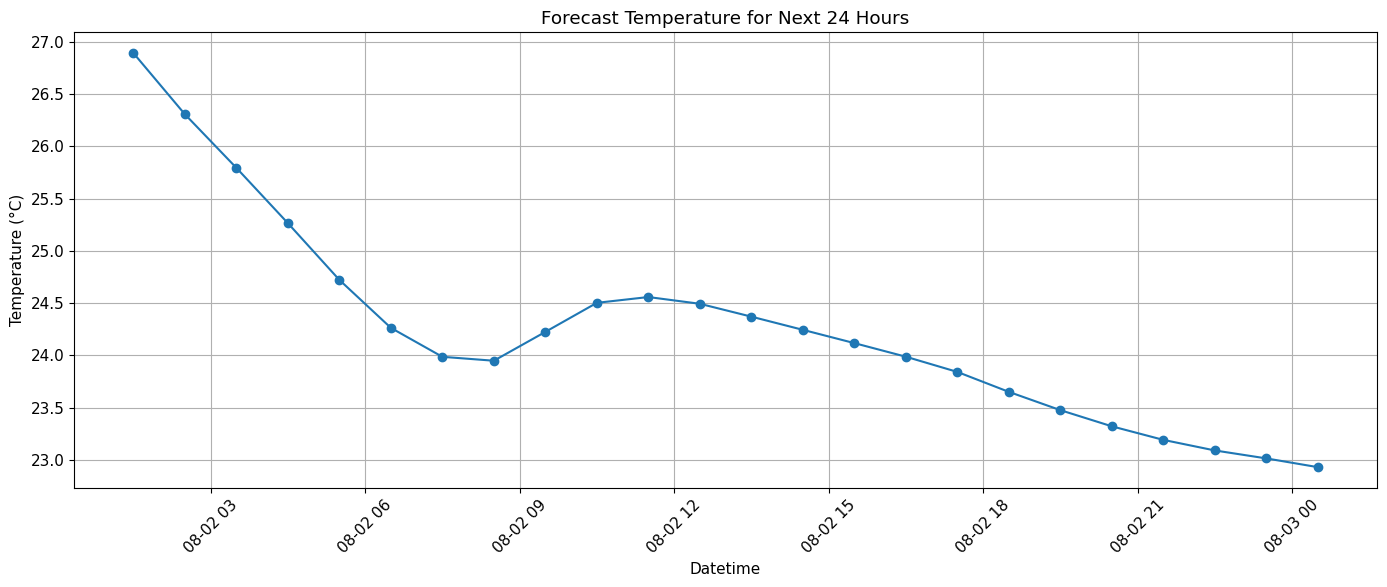

In [107]:
plt.figure(figsize=(14,6))

plt.plot(

    forecast_result["Datetime"],

    forecast_result["Predicted Temperature (°C)"],

    marker="o"

)

plt.title("Forecast Temperature for Next 24 Hours")

plt.xlabel("Datetime")

plt.ylabel("Temperature (°C)")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

In [110]:
forecast_result.to_csv(

    "forecast_next_24_hours.csv",

    index=False

)

print("="*60)
print("Forecast saved successfully.")
print("="*60)

forecast_result.head()

Forecast saved successfully.


,Datetime,Predicted Temperature (°C)
0,2026-08-02 01:29:41.941481,26.893948
1,2026-08-02 02:29:41.941481,26.307873
2,2026-08-02 03:29:41.941481,25.794793
3,2026-08-02 04:29:41.941481,25.265559
4,2026-08-02 05:29:41.941481,24.722245
